In [24]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Concatenate
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


# Load the training metadata
train_metadata = pd.read_csv('train_metadata.csv')

# View first few rows
print(train_metadata.head())


                 photo_id                                     path  \
0  B4kTLa3wuM3Mx2tqWd1Adw   train/drink/B4kTLa3wuM3Mx2tqWd1Adw.jpg   
1  ea2a28GJ8SoDdGtB5DhjAA  train/inside/ea2a28GJ8SoDdGtB5DhjAA.jpg   
2  8AOjN0DYw9QHHnuvOlKmqg    train/menu/8AOjN0DYw9QHHnuvOlKmqg.jpg   
3  I0Ya0y4YU52KuOoxmwxFMQ  train/inside/I0Ya0y4YU52KuOoxmwxFMQ.jpg   
4  0o0ZMYBNwPMKj_qSnWKnrQ    train/food/0o0ZMYBNwPMKj_qSnWKnrQ.jpg   

                                       absolute_path   label  \
0  C:\Users\bhoom\Downloads\extracted_yelp_images...   drink   
1  C:\Users\bhoom\Downloads\extracted_yelp_images...  inside   
2  C:\Users\bhoom\Downloads\extracted_yelp_images...    menu   
3  C:\Users\bhoom\Downloads\extracted_yelp_images...  inside   
4  C:\Users\bhoom\Downloads\extracted_yelp_images...    food   

              business_id                          caption  split  file_size  \
0  WwxsLX2Z-SUwiTUs8rsOKg                     Beer Flights  train      20966   
1  PkeGb4MKT2nBi_6w73pa6w  Interio

In [26]:
# Image size expected by VGG
IMG_SIZE = (224, 224)

# Base directory where 'train/' folder exists
BASE_DIR = 'train'

def load_images_from_metadata(df, base_dir=BASE_DIR):
    images = []
    labels = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Loading Images"):
        rel_path = row['path']
        full_path = os.path.join(base_dir, os.path.relpath(rel_path, start='train'))

        try:
            img = load_img(full_path, target_size=IMG_SIZE)
            img = img_to_array(img) / 255.0
            images.append(img)
            labels.append(row['label'])
        except Exception as e:
            print(f"❌ Error loading {rel_path}: {e}")

    return np.array(images), labels


In [30]:


sampled_metadata = train_metadata.sample(n=2500, random_state=42).reset_index(drop=True)
X_img, y_labels = load_images_from_metadata(sampled_metadata)


Loading Images: 100%|██████████| 2500/2500 [00:16<00:00, 150.88it/s]


In [31]:


# Step 1: Encode labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

# Step 2: Convert to one-hot encoding
y_onehot = to_categorical(y_encoded)

# Optional: Check classes
print("Classes:", label_encoder.classes_)


Classes: ['drink' 'food' 'inside' 'menu' 'outside']


In [32]:
print(sampled_metadata.columns)


Index(['photo_id', 'path', 'absolute_path', 'label', 'business_id', 'caption',
       'split', 'file_size', 'modified_time'],
      dtype='object')


In [40]:
# Extract and scale file_size
X_meta = sampled_metadata[['file_size']]
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta)

print (X_meta)

      file_size
0         31794
1         25970
2         26062
3         24377
4         18897
...         ...
2495      27361
2496      21776
2497      27905
2498      22959
2499      20063

[2500 rows x 1 columns]


In [46]:
# 1. Split the data
X_img_temp, X_img_test, X_meta_temp, X_meta_test, y_temp, y_test = train_test_split(
    X_img, X_meta_scaled, y_onehot, test_size=0.2, random_state=42, stratify=y_onehot)

X_img_train, X_img_val, X_meta_train, X_meta_val, y_train, y_val = train_test_split(
    X_img_temp, X_meta_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

# 2. Compute class weights based on y_train
y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_integers), y=y_integers)
class_weights_dict = dict(enumerate(class_weights))

In [52]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Set image input
IMG_SIZE = (224, 224)
img_input = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Load VGG16 base
vgg_base = VGG16(include_top=False, weights='imagenet', input_tensor=img_input)
vgg_output = GlobalAveragePooling2D()(vgg_base.output)

# Freeze all layers initially
for layer in vgg_base.layers:
    layer.trainable = False

# Metadata input
meta_input = Input(shape=(X_meta_scaled.shape[1],))
meta_dense = Dense(64, activation='relu')(meta_input)

# Combine image + metadata branches
combined = Concatenate()([vgg_output, meta_dense])
x = Dense(128, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(y_onehot.shape[1], activation='softmax')(x)

# Create and compile model with custom learning rate
model = Model(inputs=[img_input, meta_input], outputs=output)
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Compute class weights
y_integers = np.argmax(y_onehot, axis=1)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_integers), y=y_integers)
class_weights_dict = dict(enumerate(class_weights))

# Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# Fit the model
history = model.fit(
    [X_img_train, X_meta_train],
    y_train,
    validation_data=([X_img_val, X_meta_val], y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 385s 8s/step - accuracy: 0.2692 - loss: 1.6794 - val_accuracy: 0.5350 - val_loss: 1.4566 - learning_rate: 1.0000e-04
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 373s 7s/step - accuracy: 0.3127 - loss: 1.6817 - val_accuracy: 0.5600 - val_loss: 1.3999 - learning_rate: 1.0000e-04
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 381s 8s/step - accuracy: 0.3492 - loss: 1.6130 - val_accuracy: 0.5900 - val_loss: 1.3385 - learning_rate: 1.0000e-04
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 373s 7s/step - accuracy: 0.4028 - loss: 1.4209 - val_accuracy: 0.6400 - val_loss: 1.2793 - learning_rate: 1.0000e-04
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 365s 7s/step - accuracy: 0.4893 - loss: 1.3746 - val_accuracy: 0.6375 - val_loss: 1.2280 - learning_rate: 1.0000e-04
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 370s 7s/step - accuracy: 0.4821 - loss: 1.3316 - val_accuracy: 0.6475 - val_loss: 1.1802 - learning_rate: 1.0000e-04
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 375s 8s/step - accuracy: 0.5382 

In [ ]:
#..----------------------------=======================

In [42]:

# Image input
img_input = Input(shape=(224, 224, 3))
vgg_base = VGG16(include_top=False, weights='imagenet', input_tensor=img_input)
vgg_output = GlobalAveragePooling2D()(vgg_base.output)

# Metadata input
meta_input = Input(shape=(X_meta_scaled.shape[1],))  # e.g., (1,) for file_size
meta_dense = Dense(64, activation='relu')(meta_input)

# Combine both branches
combined = Concatenate()([vgg_output, meta_dense])
x = Dense(128, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(y_onehot.shape[1], activation='softmax')(x)

# Define model
model = Model(inputs=[img_input, meta_input], outputs=output)

optimizer = Adam(learning_rate=1e-4)  # Recommended: 1e-4 or lower for fine-tuning
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Summary (optional)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_2[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 14,789,317 (56.42 MB)

 Trainable params: 14,789,317 (56.42 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# Compute class weights
y_integers = np.argmax(y_onehot, axis=1)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_integers), y=y_integers)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)


Class Weights: {0: 1.1160714285714286, 1: 0.6476683937823834, 2: 0.6793478260869565, 3: 14.705882352941176, 4: 0.9803921568627451}


In [16]:
# Train/Test split first
X_img_temp, X_img_test, X_meta_temp, X_meta_test, y_temp, y_test = train_test_split(
    X_img, X_meta_scaled, y_onehot, test_size=0.2, random_state=42, stratify=y_onehot)

# Then Train/Val split
X_img_train, X_img_val, X_meta_train, X_meta_val, y_train, y_val = train_test_split(
    X_img_temp, X_meta_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)


In [17]:

history = model.fit(
    [X_img_train, X_meta_train],
    y_train,
    batch_size=32,
    epochs=10,
    validation_data=([X_img_val, X_meta_val], y_val),
    shuffle=True,
    class_weight=class_weights_dict,
    verbose=1
)


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 549s 27s/step - accuracy: 0.2313 - loss: 3.9887 - val_accuracy: 0.2937 - val_loss: 1.5292
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 538s 27s/step - accuracy: 0.2769 - loss: 1.7987 - val_accuracy: 0.3250 - val_loss: 1.5598
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 538s 27s/step - accuracy: 0.2807 - loss: 1.5542 - val_accuracy: 0.2500 - val_loss: 1.5703
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 538s 27s/step - accuracy: 0.2760 - loss: 1.6546 - val_accuracy: 0.3875 - val_loss: 1.5037
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 538s 27s/step - accuracy: 0.2807 - loss: 1.5831 - val_accuracy: 0.3375 - val_loss: 1.5003
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 534s 27s/step - accuracy: 0.2918 - loss: 1.4459 - val_accuracy: 0.3812 - val_loss: 1.5066
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 525s 26s/step - accuracy: 0.2378 - loss: 1.8350 - val_accuracy: 0.3250 - val_loss: 1.5473
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 520s 26s/step - accuracy: 0.2727 - loss: 1.6297 - val_accuracy: 0.

16/16 ━━━━━━━━━━━━━━━━━━━━ 85s 5s/step
✅ Test Accuracy: 0.6920
✅ Macro F1 Score: 0.6183
✅ Macro AUC Score: 0.9245


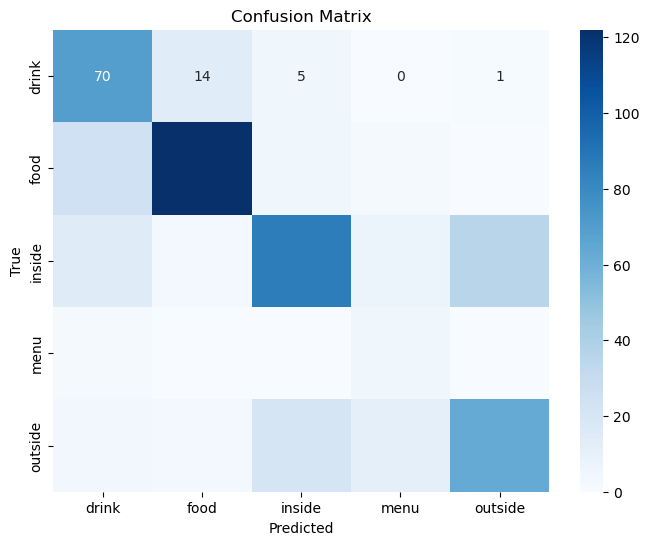

✅ Classification Report:

              precision    recall  f1-score   support

       drink       0.60      0.78      0.68        90
        food       0.86      0.79      0.82       154
      inside       0.74      0.59      0.65       147
        menu       0.20      0.71      0.31         7
     outside       0.63      0.62      0.62       102

    accuracy                           0.69       500
   macro avg       0.61      0.70      0.62       500
weighted avg       0.72      0.69      0.70       500



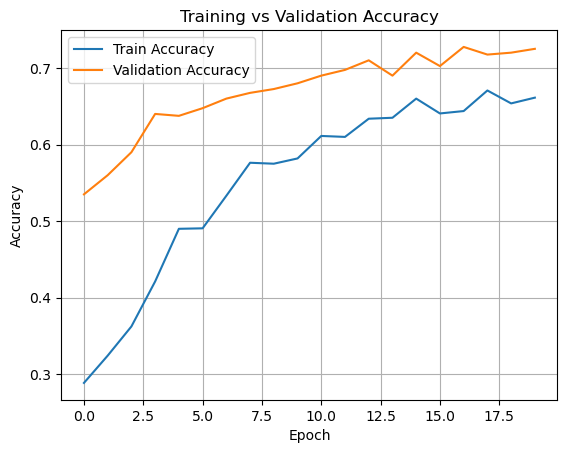

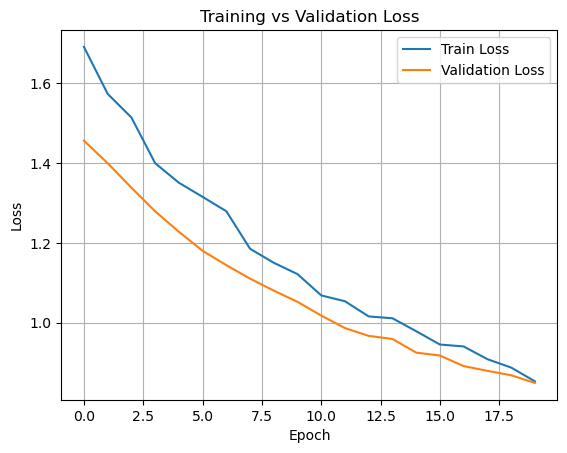

In [53]:

# Predict on test set
y_pred_proba = model.predict([X_img_test, X_meta_test])
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

# Accuracy
test_accuracy = accuracy_score(y_true, y_pred)
print(f"✅ Test Accuracy: {test_accuracy:.4f}")

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"✅ Macro F1 Score: {f1_macro:.4f}")

# AUC
auc_macro = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"✅ Macro AUC Score: {auc_macro:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report
print("✅ Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Plot accuracy and loss curves
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [56]:
model.save("vgg_model_transfer_learning_metadata.h5")